# Import packages

In [5]:
import numpy as np
import math
import pickle as pkl
import matplotlib.pyplot as plt

# Make a synthetic cable and source

In [6]:
cable_x = np.append(np.arange(100, 900, 20),np.array([880]*41))
cable_y = np.append(np.array([100]*41),np.arange(100, 900, 20))
cable_z = np.array([0]*len(cable_y))

channel_locations = np.array([cable_x, cable_y, cable_z]).T

source_x, source_y = 1500, 500

source_loc = (source_x, source_y)

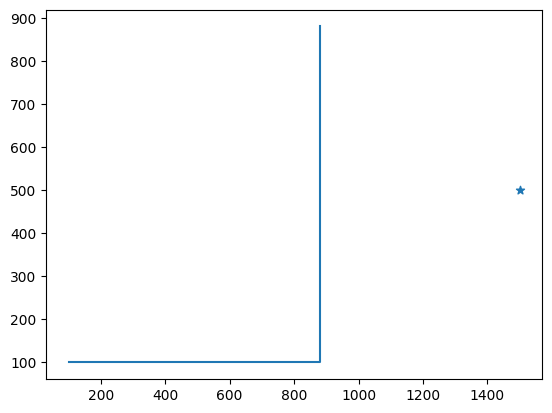

In [45]:
fig, ax = plt.subplots()

ax.plot(cable_x, cable_y)
ax.scatter(source_x, source_y, marker="*")



In [46]:
normal_vector_of_cable = []
for n in range(len(channel_locations)):
    if n == 0:
            
        x_0, y_0, z_0 = channel_locations[n]
        x_1, y_1, z_1 = channel_locations[n+1]
    else:
        x_0, y_0, z_0 = channel_locations[n-1]
        x_1, y_1, z_1 = channel_locations[n]
    dx = x_1 - x_0
    dy = y_1 - y_0

    normal_vector = (-dy,dx)

    normalized = normal_vector / np.sqrt(normal_vector[0]**2 + normal_vector[1]**2)
    if math.isnan(normalized[0]):

        normal_vector_of_cable.append(previous_normed_vector)
    else:
        normal_vector_of_cable.append(normalized)
    previous_normed_vector = normalized
normal_vector_of_cable = np.array(normal_vector_of_cable)

/tmp/ipykernel_1143722/1148030413.py:15: RuntimeWarning: invalid value encountered in divide
  normalized = normal_vector / np.sqrt(normal_vector[0]**2 + normal_vector[1]**2)


In [47]:
source_rays_to_cable = []

for n in range(len(channel_locations)):

    x_0, y_0, z_0 = channel_locations[n]

    ray = (source_x - x_0, source_y - y_0)

    ray_normalized = ray / np.sqrt((ray[0]**2 + ray[1]**2))

    source_rays_to_cable.append(ray_normalized)

source_rays_to_cable = np.array(source_rays_to_cable)

In [48]:
normal_vector_of_cable

array([[ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  1.],
       [nan, nan],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,  0.],
       [-1.,

In [49]:
source_rays_to_cable

array([[ 0.96152395,  0.27472113],
       [ 0.96046637,  0.27839605],
       [ 0.9593655 ,  0.28216632],
       [ 0.95821901,  0.28603553],
       [ 0.9570244 ,  0.2900074 ],
       [ 0.95577901,  0.29408585],
       [ 0.95447998,  0.29827499],
       [ 0.95312427,  0.30257913],
       [ 0.95170862,  0.30700278],
       [ 0.95022954,  0.31155067],
       [ 0.9486833 ,  0.31622777],
       [ 0.94706588,  0.32103928],
       [ 0.94537298,  0.32599068],
       [ 0.94359998,  0.33108771],
       [ 0.94174191,  0.3363364 ],
       [ 0.93979342,  0.34174306],
       [ 0.93774876,  0.34731436],
       [ 0.93560172,  0.35305725],
       [ 0.93334561,  0.35897908],
       [ 0.9309732 ,  0.36508753],
       [ 0.92847669,  0.37139068],
       [ 0.92584764,  0.377897  ],
       [ 0.92307692,  0.38461538],
       [ 0.92015464,  0.39155516],
       [ 0.91707006,  0.39872611],
       [ 0.91381155,  0.40613847],
       [ 0.91036648,  0.41380294],
       [ 0.90672111,  0.42173075],
       [ 0.90286052,

In [50]:
cable_sensitivity = []

for cable_v, source_v in zip(normal_vector_of_cable, source_rays_to_cable):

    cable_sensitivity.append(np.cos((np.pi/2) - np.arccos(np.dot(cable_v, source_v)))**2)

cable_sensitivity = np.array(cable_sensitivity)

In [3]:
def cable_sensitivity_func(cable_location, source_location):

    """"
    This code calculates the cable sensitivity relative a wave propogating in 
    2-dimensions with particle motions in the direction of the ray path.

    cable_location: a 2D numpy array that contains (x,y,z) of the channel locations.
    source_location: a (x,y) location of a source.
    
    """

    source_x, source_y = source_location
    normal_vector_of_cable = []
    for n in range(len(channel_locations)):
        if n == 0:
                
            x_0, y_0, z_0 = channel_locations[n]
            x_1, y_1, z_1 = channel_locations[n+1]
        else:
            x_0, y_0, z_0 = channel_locations[n-1]
            x_1, y_1, z_1 = channel_locations[n]
        dx = x_1 - x_0
        dy = y_1 - y_0

        normal_vector = (-dy,dx)

        normalized = normal_vector / np.sqrt(normal_vector[0]**2 + normal_vector[1]**2)
        if math.isnan(normalized[0]):

            normal_vector_of_cable.append(previous_normed_vector)
        else:
            normal_vector_of_cable.append(normalized)
        previous_normed_vector = normalized
    normal_vector_of_cable = np.array(normal_vector_of_cable)

    source_rays_to_cable = []

    for n in range(len(channel_locations)):

        x_0, y_0, z_0 = channel_locations[n]

        ray = (source_x - x_0, source_y - y_0)

        ray_normalized = ray / np.sqrt((ray[0]**2 + ray[1]**2))

        source_rays_to_cable.append(ray_normalized)

    source_rays_to_cable = np.array(source_rays_to_cable)

    cable_sensitivity = []

    for cable_v, source_v in zip(normal_vector_of_cable, source_rays_to_cable):

        cable_sensitivity.append(np.cos((np.pi/2) - np.arccos(np.dot(cable_v, source_v)))**2)

    cable_sensitivity = np.array(cable_sensitivity)

    return cable_sensitivity

In [7]:
cable_sensitivity = cable_sensitivity_func(channel_locations, source_loc)

/tmp/ipykernel_1169661/2759059977.py:27: RuntimeWarning: invalid value encountered in divide
  normalized = normal_vector / np.sqrt(normal_vector[0]**2 + normal_vector[1]**2)


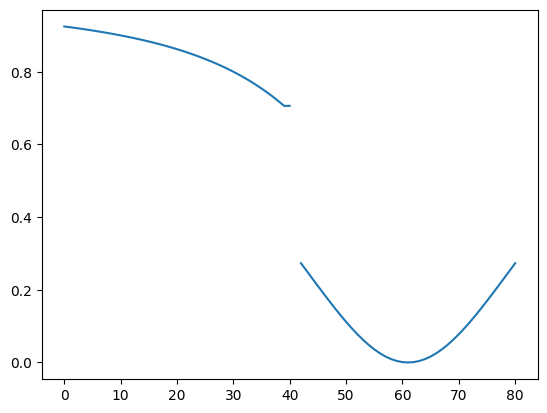

In [8]:
fig, ax = plt.subplots()

ax.plot(cable_sensitivity)